In [194]:
from collections import Counter
from datetime import datetime, timezone
import inspect
import json
import logging
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import os
from pathlib import Path
import pandas as pd
import random
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_curve
import shutil
import torch
from torch import nn, optim
from torch.amp import GradScaler, autocast
from torch.cuda import Event
import torch.nn.functional as F
from torch.nn.utils import clip_grad_norm_
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, CosineAnnealingLR, OneCycleLR, ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
from torchmetrics.classification import (BinaryAccuracy, 
                                         BinaryPrecision, 
                                         BinaryRecall, 
                                         BinaryF1Score)
from tqdm.notebook import tqdm
import warnings
import zipfile
warnings.filterwarnings("ignore", message=".*Pickle or CloudPickle.*")

In [195]:
class SystemConfig:
    IS_DETERMINISTIC = False
    MLFLOW_TRACKING_URI = "sqlite:///./mlflow-quora-questions-pairs.db"
    NEXT_LINE_COUNTER = 180
    SEED = 28
    USED_SCALER = False
    NEXT_LINE_COUNTER = 180
    @staticmethod
    def get_device():
        '''
        Detects the best available device for PyTorch.
        Priority: TPU -> GPU (CUDA) -> CPU
        '''
        # 1. Check for TPU (requires torch_xla)
        try:
            import torch_xla.core.xla_model as xm
            device = xm.xla_device()
            print(f">>> Using TPU: {device}")
        except ImportError:
            # 2. Check for GPU (CUDA)
            if torch.cuda.is_available():
                device = torch.device("cuda")
                print(f">>> Using GPU: {torch.cuda.get_device_name(0)}")
            # 3. Fallback to CPU
            else:
                device = torch.device("cpu")
                print(">>> Using CPU")
                
        return device
    DEVICE = get_device.__func__()

    @classmethod
    def to_dict(cls):
        return {
            k.lower(): v for k, v in cls.__dict__.items()
            if not k.startswith("_")
            and not inspect.isroutine(v)   # functions, methods
            and not isinstance(v, (classmethod, staticmethod))
        }

>>> Using GPU: NVIDIA GeForce GTX 1650


In [315]:
class PathConfig:
    ROOT_DIR = Path().resolve()
    EMB_DIR = ROOT_DIR.parent.parent
    EMB_PATH = EMB_DIR / "glove.6B.100d.txt"
    ARTIFACT_DIR = ROOT_DIR / "artifacts"
    MODEL_SCRIPT = ROOT_DIR / "model_architecture.py"
    NOTEBOOK_PATH = ROOT_DIR / "LSTM-attention-train.ipynb"
    DATA_DIR = ROOT_DIR / "data"
    MLFLOW_DIR = ROOT_DIR / "mlruns"
    CHECKPOINT_DIR = ARTIFACT_DIR / "checkpoint"
    CONFIG_PATH = ARTIFACT_DIR / "configs.json"
    HISTORY_PATH = ARTIFACT_DIR / "training_history.json"
    VOCABS_PATH = ARTIFACT_DIR / "vocabs.json"
    LABEL_MAPPING_PATH = ARTIFACT_DIR / "label_mapping.json"
    TRAIN_ZIP_PATH = DATA_DIR / "train.csv.zip"
    TRAIN_CSV_PATH = DATA_DIR / "train.csv"
    @classmethod
    def to_dict(cls):
        return {
            k.lower(): v for k, v in cls.__dict__.items()
            if not k.startswith("_")
            and not inspect.isroutine(v)   # functions, methods
            and not isinstance(v, (classmethod, staticmethod))
        }

In [197]:
class TokenConfig:
    PAD_TOKEN = '<PAD>'
    UNK_TOKEN = '<UNK>'
    PAD_IDX = 0
    UNK_IDX = 1
    LOWERCASE = True
    UPPERCASE = False
    MAX_LENGTH = 50
    VOCAB_SIZE = 20000
    @classmethod
    def to_dict(cls):
        return {
            k.lower(): v for k, v in cls.__dict__.items()
            if not k.startswith("_")
            and not inspect.isroutine(v)   # functions, methods
            and not isinstance(v, (classmethod, staticmethod))
        }

In [198]:
class LoaderConfig:
    BATCH_SIZE = 128
    NUM_WORKERS = 0
    IS_PIN_MEMORY = True
    @classmethod
    def to_dict(cls):
        return {
            k.lower(): v for k, v in cls.__dict__.items()
            if not k.startswith("_")
            and not inspect.isroutine(v)   # functions, methods
            and not isinstance(v, (classmethod, staticmethod))
        }

In [282]:
class ModelConfig:
    MODEL_TYPE = "LSTM_attention"
    # Embedding
    LAYER_NORM_EMB = True
    FREEZE_TOKEN_EMBEDDING = True
    TOKEN_EMBEDDING = "gloVe-6B-100d"
    EMB_DIM = 100
    EMB_DP = 0.2
    # Model
    BIDIRECTIONAL = True
    DROPOUT = 0.5
    FC_DIMS = (512,256)
    FC_NON_LINEARITY = "GELU"
    HIDDEN_DIM = 256
    ATTENTION_DROPOUT = 0.2
    LAYER_NORM_LSTM = False
    LAYER_NORM_ATTENTION = False
    ATTENTION_PROJECTION = False
    if ATTENTION_PROJECTION:
        PROJECT_DIM = HIDDEN_DIM // 2
    MASK_FILL_NUM = -1e10
    SIAMESE_CONCAT = ["difference"]
    NUM_LAYERS = 2
    SKIP_CONNECTION = False
    @classmethod
    def to_dict(cls):
        return {
            k.lower(): v for k, v in cls.__dict__.items()
            if not k.startswith("_")
            and not inspect.isroutine(v)   # functions, methods
            and not isinstance(v, (classmethod, staticmethod))
        }

In [283]:
class TrainConfig:
    LABEL_SMOOTHING = 0.1
    CLIP_NORM = 1.5
    EARLY_STOP_METRIC = "loss"
    CHECKPOINT_METRIC = "F1Score"
    if CHECKPOINT_METRIC == "loss":
        CHECKPOINT_MODE = "min"
    else:
        CHECKPOINT_MODE = "max"
    SCHEDULER_METRIC = "loss"
    EARLY_STOP_MIN_DELTA = 1e-4
    if EARLY_STOP_METRIC in ["F1Score", "Accuracy", "Precision", "Recall"]:
        EARLY_STOP_MODE = "max"
    elif EARLY_STOP_METRIC == "loss":
        EARLY_STOP_MODE = "min"
    EARLY_STOP_PATIENCE = 3
    EPOCHS = 50
    LEARNING_RATE = 3e-4
    METRICS_THRESHOLD = 0.5
    SCHEDULER_TYPE = "ReduceLROnPlateau"
    if SCHEDULER_TYPE == "ReduceLROnPlateau":
        SCHEDULER_FACTOR = 0.5
        SCHEDULER_MIN_LR = 1e-7
        SCHEDULER_PATIENCE = 2
        SCHEDULER_THRESHOLD = 0.01
        SCHEDULER_THRESHOLD_MODE = "rel"
        if SCHEDULER_METRIC in ["F1Score", "Accuracy", "Precision", "Recall"]:
            SCHEDULER_MODE = "max"
        elif SCHEDULER_METRIC == "loss":
            SCHEDULER_MODE = "min"
    elif SCHEDULER_TYPE == "CosineAnnealing":
        SCHEDULER_ETA_MIN = 1e-6
    elif SCHEDULER_TYPE == "CosineAnnealingWarmRestarts":
        SCHEDULER_T_0 = 5
        SCHEDULER_T_MUT = 2
        SCHEDULER_ETA_MIN = 1e-6
    elif SCHEDULER_TYPE == "OneCycleLR":
        SCHEDULER_PCT_START = 0.3
        SCHEDULER_DIV_FACTOR = 25
        SCHEDULER_FINAL_DIV_FACTOR = 1000

    USE_POS_WEIGHT = False
    if USE_POS_WEIGHT:
        POS_WEIGHT_STAGE = False
        if POS_WEIGHT_STAGE:
            POS_WEIGHT_EPOCH = 5
    TRAIN_TEST_SPLIT = 0.9
    UNFREEZE_EPOCH = None
    WEIGHT_DECAY = 5e-4
    @classmethod
    def to_dict(cls):
        return {
            k.lower(): v for k, v in cls.__dict__.items()
            if not k.startswith("_")
            and not inspect.isroutine(v)   # functions, methods
            and not isinstance(v, (classmethod, staticmethod))
        }

In [284]:
class PostProcessingConfig:
    INFERENCE_THRESHOLD = 0.5
    METRICS_THRESHOLD = 0.5
    @classmethod
    def to_dict(cls):
        return {
            k.lower(): v for k, v in cls.__dict__.items()
            if not k.startswith("_")
            and not inspect.isroutine(v)   # functions, methods
            and not isinstance(v, (classmethod, staticmethod))
        }

In [285]:
for path in [PathConfig.EMB_PATH, PathConfig.TRAIN_ZIP_PATH]:
    assert os.path.exists(path), f"File not found: {path}"

In [286]:
def seed_everything(seed, deterministic=False):
    '''
    Ensures absolute reproducibility.
    '''
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    if deterministic:
        # Only use these for the final "Gold" run to ensure exact results
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        print(">>> Using STRICT Deterministic mode (Slower).")
    else:
        # Benchmark=True allows cuDNN to find the fastest kernels for your hardware
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True
        print(">>> Using PROTOTYPING mode (Faster).")
    print(f">>> For Reproducibility, Everything seeded with {seed}!")



In [287]:
def set_scaler(config=SystemConfig):
    if config.USED_SCALER:
        scaler = GradScaler(device=sys_cfg.DEVICE.type, enabled=(sys_cfg.DEVICE.type == 'cuda'))
        print(">>> Scaler used in training")
    else:
        scaler = None
        print(">>> Scaler is not Used")

In [288]:
def clean_artifact_directory(artifact_dir: Path):
    if artifact_dir.exists():
        shutil.rmtree(artifact_dir)
        print(f">>> Cleaned local artifact directory: {artifact_dir}")
    artifact_dir.mkdir(parents=True, exist_ok=True)

In [289]:
sys_cfg = SystemConfig()
path_cfg = PathConfig()
token_cfg = TokenConfig()
train_cfg = TrainConfig()
loader_cfg = LoaderConfig()
model_cfg = ModelConfig()
postprc_cfg = PostProcessingConfig()
print(">>> All Configs are set successfully!")
scaler = set_scaler(sys_cfg)
seed_everything(sys_cfg.SEED, deterministic=sys_cfg.IS_DETERMINISTIC)
print(f">>> Training on: {sys_cfg.DEVICE} with seed = {sys_cfg.SEED}")

>>> All Configs are set successfully!
>>> Scaler is not Used
>>> Using PROTOTYPING mode (Faster).
>>> For Reproducibility, Everything seeded with 28!
>>> Training on: cuda with seed = 28


In [249]:
clean_artifact_directory(path_cfg.ARTIFACT_DIR)

>>> Cleaned local artifact directory: C:\Users\98922\Documents\python_scripts\AI\research-notebooks\Quora Questions Pairs\research\artifacts


In [290]:
def get_serializable_configs(configs_dict):
    """Create a JSON-serializable version of configs"""
    serializable = {}
    for section, params in configs_dict.items():
        if section not in ["system", "path"]:
            serializable[section] = params
            continue
            
        serializable[section] = {}
        
        for key, value in params.items():
            if isinstance(value, torch.device):
                # Convert torch.device to string
                serializable[section][key] = str(value)
            elif isinstance(value, Path):
                # Convert Path to string
                serializable[section][key] = str(value)
            elif key == "device":
                # Skip or convert device
                serializable[section][key] = str(value) if value.type == "cuda" else "cpu"
            else:
                serializable[section][key] = value
    
    return serializable

In [291]:
def configs_dict(config_path):
    configs = {}
    configs_names = [
        SystemConfig, PathConfig, TokenConfig, LoaderConfig, TrainConfig, ModelConfig
    ]
    for config in configs_names:
        cfg_clean = f"{config.__name__.replace("Config", "").lower()}"
        configs[cfg_clean] = config.to_dict()

    serializable_configs = get_serializable_configs(configs)
    with open(config_path, "w", encoding="utf-8") as f:
        json.dump(serializable_configs, f, ensure_ascii=False, indent=2)
    print(">>> Configs Saved as JSON File!")
    return configs

configs = configs_dict(path_cfg.CONFIG_PATH)

>>> Configs Saved as JSON File!


In [252]:
with zipfile.ZipFile(path_cfg.TRAIN_ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(path_cfg.DATA_DIR)

In [253]:
df = pd.read_csv(path_cfg.TRAIN_CSV_PATH)
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [254]:
print(f"Number of all pairs in research: {len(df)}")

Number of all pairs in research: 404290


In [255]:
df.isna().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [256]:
df["is_duplicate"].value_counts().sort_index()

is_duplicate
0    255027
1    149263
Name: count, dtype: int64

In [257]:
not_dupl = (df["is_duplicate"] == 0).sum()
is_dupl = (df["is_duplicate"] == 1).sum()
total = len(df)
print(
    f"Is duplicate in % : {is_dupl / total * 100}\n"
    f"not duplicate in % : {not_dupl / total * 100}"
)

Is duplicate in % : 36.9197853026293
not duplicate in % : 63.08021469737069


In [258]:
def clean_text(text, config=token_cfg):
    if config.LOWERCASE:
        text = text.lower()
    if config.UPPERCASE:
        text = text.upper()

    text = re.sub(r'!', ' ! ', text)
    text = re.sub(r'\?', ' ? ', text)
    text = re.sub(r'\？', ' ? ', text)
    
    text = re.sub(r'\.', ' . ', text)
    text = re.sub(r',', ' , ', text)
    text = re.sub(r'-', ' - ', text)
    text = re.sub(r'\–', ' - ', text)
    text = re.sub(r'\(', ' ( ', text)
    text = re.sub(r'\)', ' ) ', text)
    text = re.sub(r'\"', " \' ", text)
    text = re.sub(r'\\', " \\ ", text)
    text = re.sub(r'/', " / ", text)
    return text

In [259]:
def final_questions(row):
    final_q = clean_text(row, config=token_cfg)
    final_q = str(final_q)
    return final_q

In [260]:
def preprocess_df(df):
    df["question1"] = df["question1"].fillna("")
    df["question2"] = df["question2"].fillna("")
    df["question1"] = df["question1"].apply(final_questions)
    df["question2"] = df["question2"].apply(final_questions)
    print(">>> Preprocess is done!")
    return df

In [261]:
df = preprocess_df(df)

>>> Preprocess is done!


In [262]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0
1,1,3,4,what is the story of kohinoor ( koh - i - noo...,what would happen if the indian government sto...,0
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0
3,3,7,8,why am i mentally very lonely ? how can i sol...,find the remainder when [math]23^{24}[ / math]...,0
4,4,9,10,"which one dissolve in water quikly sugar , sa...",which fish would survive in salt water ?,0


In [263]:
train_df, val_df = train_test_split(
    df, random_state=sys_cfg.SEED, shuffle=True, 
    stratify=df["is_duplicate"], train_size=train_cfg.TRAIN_TEST_SPLIT
)

In [264]:
def build_vocabs(df, config=token_cfg):
    PAD_TOKEN = config.PAD_TOKEN
    PAD_IDX = config.PAD_IDX
    UNK_TOKEN = config.UNK_TOKEN
    UNK_IDX = config.UNK_IDX
    vocab_size = config.VOCAB_SIZE

    question1 = df["question1"]
    question2 = df["question2"]

    counter = Counter()
    for questions_tuple in list(zip(question1, question2)):
        q1_tokens = questions_tuple[0].split()
        counter.update(q1_tokens)
        q2_tokens = questions_tuple[1].split()
        counter.update(q2_tokens)

    most_common = counter.most_common(vocab_size - 2)
    vocabs = {
        PAD_TOKEN: PAD_IDX,
        UNK_TOKEN: UNK_IDX
    }
    for idx, (word, _) in enumerate(most_common, start=2):
        vocabs[word] = idx

    idx2word = {v:k for k, v in vocabs.items()}

    return vocabs, idx2word

In [265]:
vocabs, idx2word = build_vocabs(train_df, config=token_cfg)
vocab_size = len(vocabs)
print(f"Vocabs created! vocab size: {vocab_size}")
token_cfg.VOCAB_SIZE = vocab_size

Vocabs created! vocab size: 20000


In [266]:
def save_vocabs(stoi: dict, path: str):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    itos = {str(v): k for k, v in stoi.items()}
    payload = {
        "vocab_size": len(stoi),
        "special_tokens": {
            "pad": "<PAD>",
            "unk": "<UNK>"
        },
        "stoi": stoi,
        "itos": itos
    }
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, ensure_ascii=False, indent=2)

    print("Vocab and inverse Vocab saved as a JSON file")
save_vocabs(vocabs, path_cfg.VOCABS_PATH)

Vocab and inverse Vocab saved as a JSON file


In [267]:
label_mapping = {"0": "different", "1": "duplicated"}
with open(path_cfg.LABEL_MAPPING_PATH, "w", encoding="utf-8") as f:
    json.dump(label_mapping, f, ensure_ascii=False, indent=2)
print("Label mapping saved.")

Label mapping saved.


In [268]:
def encode_text(text, vocabs=vocabs, config=token_cfg):
    PAD_TOKEN = config.PAD_TOKEN
    UNK_TOKEN = config.UNK_TOKEN
    maxlen = config.MAX_LENGTH

    tokens = text.split()
    ids = [vocabs.get(token, vocabs[UNK_TOKEN]) for token in tokens]

    if len(ids) > maxlen:
        ids = ids[:maxlen]
    elif len(ids) < maxlen:
        ids += [vocabs[PAD_TOKEN]] * (maxlen - len(ids))

    return ids

In [269]:
def decode(ids, idx2word, pad_idx=token_cfg.PAD_IDX):
    return " ".join([idx2word.get(i, "<UNK>") for i in ids if i != pad_idx])

In [270]:
class QuoraDataset(Dataset):
    def __init__(self, df):
        self.q1 = df["question1"].values
        self.q2 = df["question2"].values
        self.label = df["is_duplicate"].values

    def __len__(self):
        return len(self.q1)

    def pos_class_weight(self, device):
        pos_num = (self.label == 1).sum()
        neg_num = (self.label == 0).sum()
        pos_weight = torch.tensor(neg_num / pos_num).to(device)

        return pos_weight

    def __getitem__(self, idx):
        encoded_q1 = encode_text(self.q1[idx])
        encoded_q2 = encode_text(self.q2[idx])
        label = self.label[idx]

        return {
            "q1": torch.LongTensor(encoded_q1),
            "q2": torch.LongTensor(encoded_q2),
            "label": torch.tensor(label, dtype=torch.float)
        }

In [271]:
train_dataset = QuoraDataset(train_df)
val_dataset = QuoraDataset(val_df)

In [272]:
for i in range(3):
    item = val_dataset[i]
    print(f"\nSample {i}")
    print("Encoded Question 1:")
    print(item["q1"].tolist())
    print(f"\tDecoded text: {decode(item["q1"].tolist(), idx2word)}")
    print("Encoded Question 2:")
    print(item["q2"].tolist())
    print(f"\tDecoded Question 2: {decode(item["q2"].tolist(), idx2word)}")
    print("\t\tLabel:", item["label"])


Sample 0
Encoded Question 1:
[6, 15, 7, 61, 76, 101, 10, 41, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
	Decoded text: how can i make money online in india ?
Encoded Question 2:
[84, 3, 606, 62, 9, 61, 76, 101, 39, 41, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
	Decoded Question 2: what's the easiest way to make money online from india ?
		Label: tensor(1.)

Sample 1
Encoded Question 1:
[4, 13, 30, 50, 1820, 55, 8117, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
	Decoded text: what are some good novels about farmers ?
Encoded Question 2:
[4, 13, 30, 50, 1820, 65, 3, 563, 5, 1093, 396, 8117, 14, 5902, 70, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
	Decoded Question 2: what are some goo

In [273]:
train_dataloader = DataLoader(
    train_dataset,
    batch_size=loader_cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=loader_cfg.NUM_WORKERS,
    pin_memory=loader_cfg.IS_PIN_MEMORY
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=loader_cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=loader_cfg.NUM_WORKERS,
    pin_memory=loader_cfg.IS_PIN_MEMORY
)

In [274]:
batch = next(iter(train_dataloader))

print(f"Batched Input IDs Size: {batch["q1"].shape}")
print(f"Batched Input IDs Size: {batch["q2"].shape}")
print(f"Batched Labels size: {batch["label"].shape}")

Batched Input IDs Size: torch.Size([128, 50])
Batched Input IDs Size: torch.Size([128, 50])
Batched Labels size: torch.Size([128])


In [275]:
unk_words_q1 = sum(
    (i == token_cfg.UNK_IDX) for text in train_df["question1"]
    for i in encode_text(text)
)
unk_words_q2 = sum(
    (i == token_cfg.UNK_IDX) for text in train_df["question2"]
    for i in encode_text(text)
)
unk_ratio = (unk_words_q1 + unk_words_q2) / (2*len(train_df["question1"]) * token_cfg.MAX_LENGTH)
print(f"Unknown Words Ratio: {unk_ratio:.4f}")

Unknown Words Ratio: 0.0049


In [276]:
def load_embedding(emb_dim, idx2word, emb_dir):
    vocab_size = len(idx2word)
    emb_matrix = np.random.normal(0.0, 1.0, (vocab_size, emb_dim))
    with open(emb_dir, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vector = np.array(parts[1:], dtype=np.float32)
            if word in idx2word:
                idx = idx2word[word]
                emb_matrix[idx] = vector

    return torch.FloatTensor(emb_matrix)

In [277]:
embedding = load_embedding(model_cfg.EMB_DIM, idx2word, path_cfg.EMB_PATH)

In [292]:
class Attention(nn.Module):
    def __init__(self, hidden_dim, mask_fill_num=model_cfg.MASK_FILL_NUM, dropout=model_cfg.ATTENTION_DROPOUT):
        super(Attention, self).__init__()
        self.W = nn.Linear(hidden_dim, hidden_dim)
        self.V = nn.Linear(hidden_dim, 1, bias=False)
        self.mask_fill_num = mask_fill_num
        self.dropout = nn.Dropout(dropout)

    def forward(self, lstm_output, mask):
        energy = torch.tanh(self.W(lstm_output))
        scores = self.V(energy).squeeze(-1)
        scores = scores.masked_fill(mask == 0, self.mask_fill_num) 
        weights = F.softmax(scores, dim=-1)
        weights = self.dropout(weights)
        lstm_masked = lstm_output * mask.unsqueeze(-1)
        weights = weights.unsqueeze(1)
        context = torch.bmm(weights, lstm_masked)
        
        return context.squeeze(1), weights

In [304]:
class QuoraSiameseClassifier(nn.Module):
    def __init__(self, vocab_size, config=model_cfg, embedding=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, config.EMB_DIM)
        self.emb_norm = nn.LayerNorm(config.EMB_DIM)
        self.emb_dropout = nn.Dropout(config.EMB_DP)
        if embedding is not None:
            print("Glove copied in Embedding Layer...")
            self.embedding.weight.data.copy_(embedding)
            self.embedding.weight.requires_grad = not config.FREEZE_TOKEN_EMBEDDING

        self.LSTM = nn.LSTM(
            input_size=config.EMB_DIM,
            hidden_size=config.HIDDEN_DIM,
            bidirectional=config.BIDIRECTIONAL,
            num_layers=config.NUM_LAYERS,
            dropout=config.DROPOUT if config.NUM_LAYERS > 1 else 0.0,
            batch_first=True
        )
        lstm_output_dim = config.HIDDEN_DIM*(2 if config.BIDIRECTIONAL else 1)
        self.attention = Attention(lstm_output_dim)
        if config.ATTENTION_PROJECTION:
            input_dim = config.PROJECT_DIM*2 + 1
            self.proj = nn.Linear(lstm_output_dim, config.PROJECT_DIM)
        else:
            input_dim = lstm_output_dim*2 + 1
            self.proj = nn.Identity()

        fc_layers = []
        for d in config.FC_DIMS:
            fc_layers += [nn.Linear(input_dim, d), nn.GELU(), nn.Dropout(config.DROPOUT)]
            input_dim = d
        fc_layers.append(nn.Linear(input_dim, 1))
        self.fc = nn.Sequential(*fc_layers)

    def _create_mask(self, question):
        return (question != 0).float()

    def _encode(self, question):
        emb = self.embedding(question)
        emb = self.emb_norm(emb)
        emb = self.emb_dropout(emb)
        mask = self._create_mask(question)
        out, _ = self.LSTM(emb)
        ctx, _ = self.attention(out, mask)
        return ctx

    def forward(self, q1, q2):
        h1, h2 = self.proj(self._encode(q1)), self.proj(self._encode(q2))
        diff = torch.abs(h1 - h2)
        prod = h1 * h2
        cosine_sim = (h1 * h2).sum(dim=-1, keepdim=True)
        feat = torch.cat([diff, prod, cosine_sim], dim=1)
        logits = self.fc(feat).squeeze(1)
        return logits

In [305]:
import os
from pathlib import Path

def write_model_architecture(export_path: Path = None):
    """
    Writes the current version of Attention and QuoraSiameseClassifier
    to the model_architecture.py file.
    
    Parameters
    ----------
    export_path : Path, optional
        Path to save the file. Defaults to PathConfig.MODEL_SCRIPT.
    """
    if export_path is None:
        export_path = path_cfg.MODEL_SCRIPT
    
    content = '''import torch
import torch.nn as nn
import torch.nn.functional as F

# ----------------------------------------------------------------------
# This file is auto-generated by the notebook. Do not edit manually.
# Import ModelConfig from the notebook or define it here for standalone use.
# ----------------------------------------------------------------------
class ModelConfig:
    MODEL_TYPE = "LSTM_attention"
    LAYER_NORM_EMB = True
    FREEZE_TOKEN_EMBEDDING = True
    TOKEN_EMBEDDING = "gloVe-6B-100d"
    EMB_DIM = 100
    EMB_DP = 0.2
    BIDIRECTIONAL = True
    DROPOUT = 0.5
    FC_DIMS = (128,)
    FC_NON_LINEARITY = "GELU"
    HIDDEN_DIM = 256
    ATTENTION_DROPOUT = 0.0
    LAYER_NORM_LSTM = False
    LAYER_NORM_ATTENTION = False
    ATTENTION_PROJECTION = False
    PROJECT_DIM = 128
    MASK_FILL_NUM = -1e10
    SIAMESE_CONCAT = ["difference"]
    NUM_LAYERS = 2
    SKIP_CONNECTION = False
    USE_BILINEAR = False
model_cfg = ModelConfig()


class Attention(nn.Module):
    def __init__(self, hidden_dim, mask_fill_num=model_cfg.MASK_FILL_NUM, dropout=model_cfg.ATTENTION_DROPOUT):
        super(Attention, self).__init__()
        self.W = nn.Linear(hidden_dim, hidden_dim)
        self.V = nn.Linear(hidden_dim, 1, bias=False)
        self.mask_fill_num = mask_fill_num
        self.dropout = nn.Dropout(dropout)

    def forward(self, lstm_output, mask):
        energy = torch.tanh(self.W(lstm_output))
        scores = self.V(energy).squeeze(-1)
        scores = scores.masked_fill(mask == 0, self.mask_fill_num)
        weights = F.softmax(scores, dim=-1)
        weights = self.dropout(weights)
        lstm_masked = lstm_output * mask.unsqueeze(-1)
        weights = weights.unsqueeze(1)
        context = torch.bmm(weights, lstm_masked)
        return context.squeeze(1), weights


class QuoraSiameseClassifier(nn.Module):
    def __init__(self, vocab_size, config=model_cfg, embedding=None):
        super().__init__()
        self.config = config
        
        self.embedding = nn.Embedding(vocab_size, config.EMB_DIM)
        self.emb_norm = nn.LayerNorm(config.EMB_DIM)
        self.emb_dropout = nn.Dropout(config.EMB_DP)
        if embedding is not None:
            print("Glove copied in Embedding Layer...")
            self.embedding.weight.data.copy_(embedding)
            self.embedding.weight.requires_grad = not config.FREEZE_TOKEN_EMBEDDING

        self.LSTM = nn.LSTM(
            input_size=config.EMB_DIM,
            hidden_size=config.HIDDEN_DIM,
            bidirectional=config.BIDIRECTIONAL,
            num_layers=config.NUM_LAYERS,
            dropout=config.DROPOUT if config.NUM_LAYERS > 1 else 0.0,
            batch_first=True
        )
        lstm_output_dim = config.HIDDEN_DIM * (2 if config.BIDIRECTIONAL else 1)
        
        self.attention = Attention(lstm_output_dim)
        
        if config.ATTENTION_PROJECTION:
            self.proj = nn.Linear(lstm_output_dim, config.PROJECT_DIM)
            feature_dim = config.PROJECT_DIM
        else:
            self.proj = nn.Identity()
            feature_dim = lstm_output_dim
        
        self.use_bilinear = getattr(config, 'USE_BILINEAR', False)
        if self.use_bilinear:
            self.bilinear = nn.Bilinear(feature_dim, feature_dim, 1)
            fc_input_dim = feature_dim + 1
        else:
            fc_input_dim = feature_dim
        
        fc_layers = []
        in_dim = fc_input_dim
        for d in config.FC_DIMS:
            fc_layers += [nn.Linear(in_dim, d), nn.GELU(), nn.Dropout(config.DROPOUT)]
            in_dim = d
        fc_layers.append(nn.Linear(in_dim, 1))
        self.fc = nn.Sequential(*fc_layers)

    def _create_mask(self, question):
        return (question != 0).float()

    def _encode(self, question):
        emb = self.embedding(question)
        emb = self.emb_norm(emb)
        emb = self.emb_dropout(emb)
        mask = self._create_mask(question)
        out, _ = self.LSTM(emb)
        ctx, _ = self.attention(out, mask)
        return ctx

    def forward(self, q1, q2):
        h1_raw = self._encode(q1)
        h2_raw = self._encode(q2)
        
        h1 = self.proj(h1_raw)
        h2 = self.proj(h2_raw)
        
        diff = torch.abs(h1 - h2)
        
        if self.use_bilinear:
            bilinear_sim = self.bilinear(h1, h2)
            feat = torch.cat([diff, bilinear_sim], dim=1)
        else:
            feat = diff
        
        logits = self.fc(feat).squeeze(1)
        return logits
'''
    # Write the file
    export_path.parent.mkdir(parents=True, exist_ok=True)
    with open(export_path, 'w', encoding='utf-8') as f:
        f.write(content)
    print(f">>> model_architecture.py written to {export_path}")

write_model_architecture()

>>> model_architecture.py written to C:\Users\98922\Documents\python_scripts\AI\research-notebooks\Quora Questions Pairs\research\model_architecture.py


In [306]:
model = QuoraSiameseClassifier(
    vocab_size=token_cfg.VOCAB_SIZE,
    config=model_cfg,
    embedding=embedding
).to(sys_cfg.DEVICE)
print(model)

Glove copied in Embedding Layer...
QuoraSiameseClassifier(
  (embedding): Embedding(20000, 100)
  (emb_norm): LayerNorm((100,), eps=1e-05, elementwise_affine=True)
  (emb_dropout): Dropout(p=0.2, inplace=False)
  (LSTM): LSTM(100, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (attention): Attention(
    (W): Linear(in_features=512, out_features=512, bias=True)
    (V): Linear(in_features=512, out_features=1, bias=False)
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (proj): Identity()
  (fc): Sequential(
    (0): Linear(in_features=1025, out_features=512, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.5, inplace=False)
    (6): Linear(in_features=256, out_features=1, bias=True)
  )
)


In [307]:
num_params = sum(p.numel() for p in model.parameters())
print(f"Total Number of Parameters: {sum(p.numel() for p in model.parameters())}")
print(f"Trainable Number of Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")


Total Number of Parameters: 5230409
Trainable Number of Parameters: 3230409


In [308]:
class EarlyStopping:
    def __init__(self, patience=5, mode="min", min_delta=0.0):
        self.patience = patience
        self.mode = mode
        self.min_delta = min_delta

        self.should_stop = False
        self.best_score = None
        self.counter = 0

    def step(self, current_score):
        if self.best_score is None:
            self.best_score = current_score
            return True

        if self.mode == "min":
            improvement = self.best_score - current_score > self.min_delta
        else:
            improvement = current_score - self.best_score > self.min_delta

        if improvement:
            self.best_score = current_score
            self.counter = 0
            return True
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
            return False

In [309]:
class TrainingHistory:
    def __init__(self):
        self.history = {
            "train_loss": [],
            "val_loss": [],
            "train_accuracy": [],
            "train_precision": [],
            "train_recall": [],
            "train_f1score": [],
            "val_accuracy": [],
            "val_precision": [],
            "val_recall": [],
            "val_f1score": [],
            "lr": []
        }

    def update(self, train_loss, val_loss, train_metrics, val_metrics, optimizer):
        self.history["train_loss"].append(train_loss)
        self.history["val_loss"].append(val_loss)
        for k_t, v_t in train_metrics.items():
            self.history[f"train_{k_t.lower()}"].append(v_t)
        for k_v, v_v in val_metrics.items():
            self.history[f"val_{k_v.lower()}"].append(v_v)
        self.history["lr"].append(optimizer.param_groups[0]["lr"])

    def save(self, path: str):
        """Save training history to a JSON file."""
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        with open(path, "w", encoding="utf-8") as f:
            json.dump(self.history, f, ensure_ascii=False, indent=2)

        print(f"Training History saved successfully at {path}")

    @classmethod
    def load(cls, path: str):
        "Load training history from a JSON file."
        path = Path(path)
        if not path.exists():
            raise FileNotFoundError(f"No file Found at {path}")
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)

        obj = cls()
        obj.history = data

        return obj

In [310]:
class MLflowTracker:
    def __init__(self, project_name, run_type, version, config_dict, mlflow_dir, tracking_uri=None):
        model_type = config_dict["model"]["model_type"]
        experiment_name = f"{project_name}/{model_type}" 
        self.model_type = model_type
        self.run_name = f"{model_type}-V{version}"
        self.run_type = run_type
        self.version = version
        self.config_dict = config_dict
        if tracking_uri:
            mlflow.set_tracking_uri(tracking_uri)
        else:
            mlflow.set_tracking_uri("http://localhost:5000")

        experiment = mlflow.get_experiment_by_name(experiment_name)
        artifact_dir = (mlflow_dir / project_name / model_type).as_uri()
        if experiment is None:
            mlflow.create_experiment(
                name=experiment_name,
                artifact_location=artifact_dir
            )
            print(f">>> Created new experiment: {experiment_name}")
        else:
            print(f">>> Using existing experiment: {experiment_name}")

        mlflow.set_experiment(experiment_name)
        
    def start_run(self):
        self.run = mlflow.start_run(run_name=self.run_name)
        self.run_id = self.run.info.run_id
        return self.run

    def log_param(self, param_name, param):
        mlflow.log_param(param_name, param)
    def log_params(self, params):
        mlflow.log_params(params)
    def log_config_params(self):
        for key, value in self.config_dict.items():
            if key not in ["system", "path"]:
                mlflow.log_params(value) 
        
    def _log_losses(self, train_loss, val_loss, epoch):
        mlflow.log_metric("train_loss", train_loss, step=epoch)
        mlflow.log_metric("val_loss", val_loss, step=epoch)
    def _log_metrics(self, metrics_dict, epoch, prefix):
        for metric, value in metrics_dict.items():
            mlflow.log_metric(f"{prefix}_{metric.lower()}", value, step=epoch)
    def log_epoch(self, epoch, train_loss, val_loss, train_results, val_results, lr):
        self._log_losses(train_loss, val_loss, epoch)
        self._log_metrics(train_results, epoch, prefix="train")
        self._log_metrics(val_results, epoch, prefix="val")
        mlflow.log_metric("learning_rate", lr)
    def save_state_dict(self, state_dict, checkpoint_path):
        mlflow.pytorch.save_state_dict(
            state_dict,
            path=checkpoint_path
        )

    def load_state_dict(self, model, checkpoint_path):
        loaded_state_dict = mlflow.pytorch.load_state_dict(
            checkpoint_path
        )
        model.load_state_dict(loaded_state_dict)
        return model
    def log_best_model(self, model):
        mlflow_logger = logging.getLogger("mlflow.pytorch")
        original_level = mlflow_logger.level
        mlflow_logger.setLevel(logging.ERROR)

        mlflow.pytorch.log_model(
            model,
            name="best_models",
            registered_model_name=self.run_name
        )

        mlflow_logger.setLevel(original_level)
    def log_artifact(self, artifact_path):
        mlflow.log_artifact(artifact_path)

    def log_artifact_folder(self, artifact_folder):
        mlflow.log_artifacts(artifact_folder)

    def build_run_summary(self, best_threshold, training_metrics, calibrated_metrics, total_time, avg_time_per_epoch):
        summary = {
            "generated_at_utc": datetime.now(timezone.utc).isoformat(),
            "run_type": self.run_type,
            "model_type": self.model_type,
            "run_id": self.run_id,
            "best_metrics_in_training": training_metrics,
            "best_threshold": best_threshold,
            "best_calibrated_metrics": calibrated_metrics,
            "total_training_time_in_min": total_time,
            "average_training_time_per_epoch": avg_time_per_epoch,
            "params": {}
        }
        for k, v in self.config_dict.items():
            if k not in ["system", "path"]:
                summary["params"][k] = v

        return summary
    def log_summary(self, summary, artifact_name="run_sammary.json"):
        mlflow.log_dict(summary, artifact_name)

    def log_history(self, history, artifact_name="training_history.json"):
        mlflow.log_dict(history, artifact_name)

    def set_final_tags(self, best_score, best_calib_score, best_threshold, total_training_time):
        mlflow.set_tags({
            "status": "completed",
            "model_type": self.model_type,
            "version": self.version,
            "best_training_score": best_score,
            "best_calibrated_score": best_calib_score,
            "best_threshold": best_threshold,
            "total_training_time_in_min": total_training_time
        })

In [311]:
class Trainer:
    def __init__(
        self,
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        device,
        history,
        mlflow_tracker,
        config=train_cfg,
        scaler=None
    ):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.history = history
        self.config = config
        self.criterion = criterion
        self.pos_weight = getattr(criterion, "pos_weight", None)
        self.optimizer = optimizer
        self.tracker = mlflow_tracker
        self.scaler = scaler
        
        self.early_stopper = EarlyStopping(
            patience=config.EARLY_STOP_PATIENCE,
            mode=config.EARLY_STOP_MODE,
            min_delta=config.EARLY_STOP_MIN_DELTA
        )
        self.scheduler = self._create_scheduler(config.SCHEDULER_TYPE)

        threshold = config.METRICS_THRESHOLD
        metrics_cls = [BinaryAccuracy, BinaryPrecision, BinaryRecall, BinaryF1Score]
        self.train_metrics = {m.__name__.replace("Binary", ""): m(threshold).to(device) for m in metrics_cls}
        self.val_metrics = {m.__name__.replace("Binary", ""): m(threshold).to(device) for m in metrics_cls}

        self.best_checkpoint_score = float('-inf') if config.CHECKPOINT_MODE == 'max' else float('inf')
        self.checkpoint_mode = config.CHECKPOINT_MODE

        self.train_start = Event(enable_timing=True)
        self.train_end = Event(enable_timing=True)
        self.epoch_start = Event(enable_timing=True)
        self.epoch_end = Event(enable_timing=True)
        self.epoch_durations = []

        self.current_epoch = 0

    def _bce_with_label_smoothing(self, logits, targets):
        eff_pos_weight = None
        if self.config.USE_POS_WEIGHT:
            if self.config.POS_WEIGHT_STAGE and self.current_epoch < self.config.POS_WEIGHT_EPOCH:
                eff_pos_weight = torch.tensor(1.0, device=self.pos_weight.device)
            else:
                eff_pos_weight = self.pos_weight
        smoothing = self.config.LABEL_SMOOTHING
        smooth_targets = targets * (1 - smoothing) + 0.5 * smoothing
        return F.binary_cross_entropy_with_logits(
            logits, smooth_targets, pos_weight=eff_pos_weight
        )
    def _create_scheduler(self, scheduler_type):
        if scheduler_type == "CosineAnnealing":
            return CosineAnnealingLR(
                optimizer=self.optimizer,
                T_max=self.config.EPOCHS,
                eta_min=self.config.SCHEDULER_ETA_MIN
            )
        elif scheduler_type == "ReduceLROnPlateau":
            return ReduceLROnPlateau(
                optimizer=self.optimizer,
                patience=self.config.SCHEDULER_PATIENCE,
                factor=self.config.SCHEDULER_FACTOR,
                mode=self.config.SCHEDULER_MODE,
                min_lr=self.config.SCHEDULER_MIN_LR,
                threshold=self.config.SCHEDULER_THRESHOLD,
                threshold_mode=self.config.SCHEDULER_THRESHOLD_MODE
            )
        elif scheduler_type == "OneCycleLR":
            return OneCycleLR(
                optimizer=self.optimizer,
                max_lr=self.config.LEARNING_RATE,
                epochs=self.config.EPOCHS,
                steps_per_epoch=len(self.train_loader),
                pct_start=self.config.SCHEDULER_PCT_START,        
                div_factor=self.config.SCHEDULER_DIV_FACTOR,        
                final_div_factor=self.config.SCHEDULR_FINAL_DIV_FACTOR 
            )
        elif scheduler_type == "CosineAnnealingWarmRestarts":
            return CosineAnnealingWarmRestarts(
                optimizer=self.optimizer,
                T_0=self.config.SCHEDULER_T_0,
                T_mult=self.config.SCHEDULER_T_MULT,
                eta_min=self.config.SCHEDULER_ETA_MIN
            )
        else:
            print("Warning! No Scheduler is being used!")
        print(f">>> Scheduler: {scheduler_type}")
        return None

    def _check_scheduler(self, scheduler_value):
        if self.scheduler:
            if isinstance(self.scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                old_lr = self.optimizer.param_groups[0]["lr"]
                self.scheduler.step(scheduler_value)
                new_lr = self.optimizer.param_groups[0]["lr"]
                if new_lr < old_lr:
                    print(f">>> LR reduced: {old_lr:.6f} → {new_lr:.6f}")
            else:
                self.scheduler.step()
    
    def _unfreeze_embedding(self):
        self.model.embedding.weight.requires_grad = True
        print(">>> Embedding unfrozen (LR unchanged)")

    def _reset_metrics(self, metrics_dict):
        for metric in metrics_dict.values():
            metric.reset()
    
    def _update_metrics(self, metrics_dict, probs, labels):
        for metric in metrics_dict.values():
            metric.update(probs, labels)
    
    def _compute_metrics(self, metrics_dict):
        return {k:m.compute().item() for k, m in metrics_dict.items()}

    def _get_metric_value(self, metric_name, val_loss, val_results):
        if metric_name == "loss":
            return val_loss
        else:
            return val_results[metric_name]

    def _is_checkpoint_better(self, current_value: float) -> bool:
        if self.checkpoint_mode == 'max':
            return current_value > self.best_checkpoint_score
        else:
            return current_value < self.best_checkpoint_score

    def _backprop_with_scaler(self, q1, q2, labels):
        with autocast(enabled=self.scaler is not None, device_type=str(self.device)):
            logits = self.model(q1, q2)
            loss = self._bce_with_label_smoothing(logits, labels)
        if self.scaler is not None:
            self.scaler.scale(loss).backward()

            if self.config.CLIP_NORM is not None and self.config.CLIP_NORM > 0:
                self.scaler.unscale_(self.optimizer)
                clip_grad_norm_(self.model.parameters(), self.config.CLIP_NORM)
            else:
                self.scaler.unscale_(self.optimizer)

            self.scaler.step(self.optimizer)
            self.scaler.update()
        else:
            loss.backward()
            if self.config.CLIP_NORM is not None and self.config.CLIP_NORM > 0:
                clip_grad_norm_(self.model.parameters(), self.config.CLIP_NORM)
                
            self.optimizer.step()

        return loss, logits
            
    def train_one_epoch(self):
        self.model.train()
        self._reset_metrics(self.train_metrics)
        total_loss = 0.0

        for batch in tqdm(self.train_loader, desc="Train", leave=True):
            q1 = batch["q1"].to(self.device)
            q2 = batch["q2"].to(self.device)
            labels = batch["label"].to(self.device)

            self.optimizer.zero_grad()
            
            loss, logits = self._backprop_with_scaler(q1, q2, labels)
            
            total_loss += (loss.item() * q1.size(0))

            probs = torch.sigmoid(logits)
            self._update_metrics(self.train_metrics, probs, labels)

        total_loss /= len(self.train_loader.dataset)
        results = self._compute_metrics(self.train_metrics)
        return total_loss, results

    @torch.no_grad
    def evaluate(self):
        self.model.eval()
        self._reset_metrics(self.val_metrics)
        total_loss = 0.0

        for batch in tqdm(self.val_loader, desc="Validation", leave=True):
            q1 = batch["q1"].to(self.device)
            q2 = batch["q2"].to(self.device)
            labels = batch["label"].to(self.device)

            logits = self.model(q1, q2)
            loss = self._bce_with_label_smoothing(logits, labels)
            total_loss += (loss.item() * q1.size(0))

            probs = torch.sigmoid(logits)
            self._update_metrics(self.val_metrics, probs, labels)

        total_loss /= len(self.val_loader.dataset)
        results = self._compute_metrics(self.val_metrics)

        return total_loss, results

    def log_one_epoch(self, train_loss, train_results, val_loss, val_results, lr):
        print(
            f"Training Results:\n\tLoss --> {train_loss:.4f}"
        )
        train_string = ""
        val_string = ""
        for k, v in train_results.items():
            train_result = f"{k} --> {v:.4f} | "
            train_string += train_result
        print(f"\t{train_string}")
        print(f"\tLearning Rate --> {lr:.4f}\n")
        print(
            f"Validation Results:\n\tLoss --> {val_loss:.4f}"
            )
        for k, v in val_results.items():
            val_result = f"{k} --> {v:.4f} | "
            val_string += val_result
        print(f"\t{val_string}")

    @torch.no_grad()
    def find_optimal_threshold(self):
        self.model.eval()
        all_probs, all_labels = [], []
        for batch in self.val_loader:
            q1 = batch["q1"].to(self.device)
            q2 = batch["q2"].to(self.device)
            labels = batch["label"].cpu().numpy()
            logits = self.model(q1, q2)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels)
    
        precision, recall, thresholds = precision_recall_curve(all_labels, all_probs)
        f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
        best_idx = np.argmax(f1_scores)
        best_threshold = thresholds[best_idx]
        best_f1 = f1_scores[best_idx]
        best_precision = precision[best_idx]
        best_recall = recall[best_idx]

        preds = (all_probs >= best_threshold).astype(int)
        best_accuracy = accuracy_score(all_labels, preds)
        results = {
            "Accuracy": best_accuracy,
            "Recall": best_recall,
            "Precision": best_precision,
            "F1Score": best_f1
        }
    
        print(f"Optimal threshold: {best_threshold:.4f}")
        print(f"At that threshold → F1: {best_f1:.4f}, Precision: {best_precision:.4f}, Recall: {best_recall:.4f}")
        return best_threshold, results
    
    def fit(self, num_epochs, config=path_cfg):
        self.train_start.record()
        
        print(">>> Training Started...")
        with self.tracker.start_run() as run:
            self.tracker.log_config_params()
            self.tracker.log_artifact(config.VOCABS_PATH)
            self.tracker.log_artifact(config.LABEL_MAPPING_PATH)
            self.tracker.log_artifact(config.CONFIG_PATH)
            self.tracker.log_artifact(config.MODEL_SCRIPT)

            best_metrics = {}
            
            for epoch in range(num_epochs):
                self.current_epoch = epoch
                print(f"Epoch {epoch+1}/{num_epochs}")
                self.epoch_start.record()
                torch.cuda.synchronize()
                
                if self.config.UNFREEZE_EPOCH is not None and epoch == self.config.UNFREEZE_EPOCH:
                    print(f">>> Embedding is unfrozen from epoch {epoch+1}")
                    self._unfreeze_embedding()
                
                train_loss, train_results = self.train_one_epoch()
                val_loss, val_results = self.evaluate()

                early_stop_value = self._get_metric_value(
                    self.config.EARLY_STOP_METRIC, val_loss, val_results
                )
                scheduler_value = self._get_metric_value(
                    self.config.SCHEDULER_METRIC, val_loss, val_results
                )
                checkpoint_value = self._get_metric_value(
                    self.config.CHECKPOINT_METRIC, val_loss, val_results
                )
        
                self._check_scheduler(scheduler_value)
                    
                self.history.update(
                    train_loss=train_loss,
                    val_loss=val_loss,
                    train_metrics=train_results,
                    val_metrics=val_results,
                    optimizer=self.optimizer
                )
        
                lr = self.optimizer.param_groups[0]["lr"]
                self.log_one_epoch(
                    train_loss=train_loss,
                    train_results=train_results,
                    val_loss=val_loss,
                    val_results=val_results,
                    lr=lr
                )
                self.tracker.log_epoch(
                    epoch=epoch,
                    train_loss=train_loss,
                    val_loss=val_loss,
                    train_results=train_results,
                    val_results=val_results,
                    lr=lr
                )
                trigger_early_stop = self.early_stopper.step(early_stop_value)
                is_better_checkpoint = False
                if self._is_checkpoint_better(checkpoint_value):
                    self.best_checkpoint_score = checkpoint_value 
                    best_metrics = val_results
                    self.tracker.save_state_dict(self.model.state_dict(), config.CHECKPOINT_DIR)
                    print(f">>> Best model saved! ({self.config.CHECKPOINT_METRIC} --> {checkpoint_value:.4f})")
                    
                if self.early_stopper.should_stop:
                    print(f">>> Early stopping triggered at Epoch {epoch+1}")
                    break

                self.epoch_end.record()
                torch.cuda.synchronize()
                
                epoch_duration = self.epoch_start.elapsed_time(self.epoch_end) / 1000
                self.epoch_durations.append(epoch_duration)
                print("="*sys_cfg.NEXT_LINE_COUNTER)


            self.train_end.record()
            torch.cuda.synchronize()
            total_training_time = self.train_start.elapsed_time(self.train_end) / 1000
            avg_time_per_epoch = sum(self.epoch_durations) / len(self.epoch_durations)
            total_training_time_in_min = round(total_training_time/60, 4)
            avg_time_per_epoch_in_min = round(avg_time_per_epoch/60, 4)

            self.model = self.tracker.load_state_dict(self.model, config.CHECKPOINT_DIR)
            self.model.eval()
            best_threshold, calibrated_results = self.find_optimal_threshold()
            self.tracker.log_artifact_folder(config.CHECKPOINT_DIR)
            self.tracker.log_best_model(self.model)
            print(">>> The Best Model registered at MLflow successfully!")
            summary = self.tracker.build_run_summary(
                training_metrics=best_metrics,
                calibrated_metrics=calibrated_results,
                total_time=total_training_time_in_min,
                best_threshold=best_threshold,
                avg_time_per_epoch=avg_time_per_epoch_in_min
            )
            self.tracker.log_param(
                f"best_training_{self.config.CHECKPOINT_METRIC}", 
                self.best_checkpoint_score
            )
            self.tracker.log_param(
                f"best_calibrated_{self.config.CHECKPOINT_METRIC}", 
                calibrated_results[self.config.CHECKPOINT_METRIC]
            )
            self.tracker.log_param("best_threshold", best_threshold)
            self.tracker.log_params(calibrated_results)
            self.tracker.log_param("total_training_time_in_min", total_training_time_in_min)
            self.tracker.log_param("average_time_per_epoch_in_min", avg_time_per_epoch_in_min)
            self.tracker.log_summary(summary)
            self.tracker.log_history(self.history)
            self.tracker.set_final_tags(
                best_score=self.best_checkpoint_score,
                best_calib_score=calibrated_results[self.config.CHECKPOINT_METRIC],
                best_threshold=best_threshold,
                total_training_time=total_training_time_in_min
            )
            self.tracker.log_history(self.history)
            self.tracker.log_artifact(config.NOTEBOOK_PATH)

In [312]:
mlflow_tracker = MLflowTracker(
    project_name="Quora-Question-Pairs",
    run_type="exploring-best-models",
    version=1,
    config_dict=configs,
    mlflow_dir=path_cfg.MLFLOW_DIR,
    tracking_uri=sys_cfg.MLFLOW_TRACKING_URI
)
history = TrainingHistory()
pos_weight = train_dataset.pos_class_weight(sys_cfg.DEVICE)
criterion = nn.BCEWithLogitsLoss(
    pos_weight=train_dataset.pos_class_weight(sys_cfg.DEVICE) if train_cfg.USE_POS_WEIGHT else None
)
optimizer = torch.optim.AdamW([
    {'params': [p for n, p in model.named_parameters() if 'embedding' not in n], 
     'lr': train_cfg.LEARNING_RATE},
    {'params': [model.embedding.weight], 
     'lr': train_cfg.LEARNING_RATE / 10, 
     'requires_grad': False}
], weight_decay=train_cfg.WEIGHT_DECAY)

>>> Using existing experiment: Quora-Question-Pairs/LSTM_attention


In [313]:
trainer = Trainer(
    model=model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    device=sys_cfg.DEVICE,
    history=history,
    config=train_cfg,
    mlflow_tracker=mlflow_tracker,
    scaler=scaler
)

In [314]:
trainer.fit(
    num_epochs=train_cfg.EPOCHS,
    config=path_cfg,
)

>>> Training Started...
Epoch 1/50


Train:   0%|          | 0/2843 [00:00<?, ?it/s]

Validation:   0%|          | 0/316 [00:00<?, ?it/s]

Training Results:
	Loss --> 0.5545
	Accuracy --> 0.7332 | Precision --> 0.6751 | Recall --> 0.5350 | F1Score --> 0.5969 | 
	Learning Rate --> 0.0003

Validation Results:
	Loss --> 0.5224
	Accuracy --> 0.7673 | Precision --> 0.6413 | Recall --> 0.8391 | F1Score --> 0.7270 | 
>>> Best model saved! (F1Score --> 0.7270)
Epoch 2/50


Train:   0%|          | 0/2843 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/316 [00:00<?, ?it/s]

Training Results:
	Loss --> 0.3576
	Accuracy --> 0.8989 | Precision --> 0.8623 | Recall --> 0.8641 | F1Score --> 0.8632 | 
	Learning Rate --> 0.0001

Validation Results:
	Loss --> 0.4640
	Accuracy --> 0.8330 | Precision --> 0.7158 | Recall --> 0.9085 | F1Score --> 0.8007 | 
>>> Best model saved! (F1Score --> 0.8007)
>>> Early stopping triggered at Epoch 16
Optimal threshold: 0.6823
At that threshold → F1: 0.8116, Precision: 0.7730, Recall: 0.8542


Registered model 'LSTM_attention-V1' already exists. Creating a new version of this model...
Created version '4' of model 'LSTM_attention-V1'.


>>> The Best Model registered at MLflow successfully!


FileNotFoundError: [WinError 2] The system cannot find the file specified

In [72]:
model = QuoraSiameseClassifier(
    vocab_size=vocab_size,
    config=model_cfg,
    embedding=None
).to(sys_cfg.DEVICE)

In [73]:
from mlflow.pytorch import load_state_dict
checkpoint_path = "./mlruns/Quora-Question-Pairs/LSTM_attention/e079c52d606c470cac78fd2e693800db/artifacts/"
state_dict = load_state_dict(checkpoint_path)  # path to the artifact URI
model.load_state_dict(state_dict)

<All keys matched successfully>

In [74]:
# ---- DIAGNOSTIC PATCH ----
def forward_diagnostic(self, q1, q2):
    """
    Temporary forward pass that returns logits AND cosine similarities.
    We'll replace the model's forward with this for analysis.
    """
    # Replicate the exact forward logic from your current model
    h1_raw = self._encode(q1)
    h2_raw = self._encode(q2)
    
    h1 = self.proj(h1_raw)
    h2 = self.proj(h2_raw)
    
    # Normalization (as in your current setup)
    h1_norm = F.normalize(h1, p=2, dim=-1)
    h2_norm = F.normalize(h2, p=2, dim=-1)
    
    diff = torch.abs(h1_norm - h2_norm)
    prod = h1_norm * h2_norm
    cosine_sim = (h1_norm * h2_norm).sum(dim=-1, keepdim=True)
    
    feat = torch.cat([diff, prod, cosine_sim], dim=1)
    logits = self.fc(feat).squeeze(1)
    
    return {
        "logits": logits,
        "cosine": cosine_sim.squeeze(1),   # shape (batch,)
    }

# Temporarily bind the diagnostic method
import types
model.forward_diagnostic = types.MethodType(forward_diagnostic, model)
print(">>> Diagnostic forward method attached.")

>>> Diagnostic forward method attached.


In [75]:
@torch.no_grad()
def run_phase1_diagnostic(model, dataloader, device):
    model.eval()
    all_labels = []
    all_probs = []
    all_cosines = []
    
    for batch in tqdm(dataloader, desc="Phase 1 Diagnostic"):
        q1 = batch["q1"].to(device)
        q2 = batch["q2"].to(device)
        labels = batch["label"].cpu().numpy()
        
        outputs = model.forward_diagnostic(q1, q2)
        probs = torch.sigmoid(outputs["logits"]).cpu().numpy()
        cosines = outputs["cosine"].cpu().numpy()
        
        all_labels.extend(labels)
        all_probs.extend(probs)
        all_cosines.extend(cosines)
    
    import pandas as pd
    import numpy as np
    
    df = pd.DataFrame({
        "label": all_labels,
        "prob": all_probs,
        "cosine": all_cosines
    })
    
    # Analysis
    fp = df[(df["label"] == 0) & (df["prob"] > 0.5)]
    tp = df[(df["label"] == 1) & (df["prob"] > 0.5)]
    tn = df[(df["label"] == 0) & (df["prob"] <= 0.5)]
    fn = df[(df["label"] == 1) & (df["prob"] <= 0.5)]
    
    print("\n" + "="*60)
    print("PHASE 1 DIAGNOSTIC RESULTS")
    print("="*60)
    print(f"Total validation samples: {len(df)}")
    print(f"False Positives (FP): {len(fp)}  ({len(fp)/len(df)*100:.2f}%)")
    print(f"True Positives  (TP): {len(tp)}  ({len(tp)/len(df)*100:.2f}%)")
    print(f"True Negatives  (TN): {len(tn)}  ({len(tn)/len(df)*100:.2f}%)")
    print(f"False Negatives (FN): {len(fn)}  ({len(fn)/len(df)*100:.2f}%)")
    print("\n--- Cosine Similarity Statistics ---")
    print(f"All negatives (label=0): mean={df[df['label']==0]['cosine'].mean():.4f} ± {df[df['label']==0]['cosine'].std():.4f}")
    print(f"False Positives only  : mean={fp['cosine'].mean():.4f} ± {fp['cosine'].std():.4f}")
    print(f"True Positives only   : mean={tp['cosine'].mean():.4f} ± {tp['cosine'].std():.4f}")
    print(f"All positives (label=1): mean={df[df['label']==1]['cosine'].mean():.4f} ± {df[df['label']==1]['cosine'].std():.4f}")
    print("\n--- Cosine Distribution Overlap ---")
    # Binned counts for positives and negatives
    bins = np.linspace(-1, 1, 21)
    pos_cos = df[df['label']==1]['cosine']
    neg_cos = df[df['label']==0]['cosine']
    print("Bin       Pos_count   Neg_count")
    for i in range(len(bins)-1):
        low, high = bins[i], bins[i+1]
        p_cnt = ((pos_cos >= low) & (pos_cos < high)).sum()
        n_cnt = ((neg_cos >= low) & (neg_cos < high)).sum()
        if p_cnt > 0 or n_cnt > 0:
            print(f"[{low:.2f}, {high:.2f}): {p_cnt:6d}      {n_cnt:6d}")
    
    return df

# Run it
df_diag = run_phase1_diagnostic(model, val_dataloader, sys_cfg.DEVICE)

Phase 1 Diagnostic: 100%|████████████████████████████████████████████████████████████| 316/316 [00:19<00:00, 16.18it/s]


PHASE 1 DIAGNOSTIC RESULTS
Total validation samples: 40429
False Positives (FP): 5958  (14.74%)
True Positives  (TP): 13539  (33.49%)
True Negatives  (TN): 19545  (48.34%)
False Negatives (FN): 1387  (3.43%)

--- Cosine Similarity Statistics ---
All negatives (label=0): mean=0.4391 ± 0.2976
False Positives only  : mean=0.7338 ± 0.1404
True Positives only   : mean=0.8360 ± 0.1183
All positives (label=1): mean=0.8042 ± 0.1603

--- Cosine Distribution Overlap ---
Bin       Pos_count   Neg_count
[-0.60, -0.50):      0           1
[-0.50, -0.40):      0          10
[-0.40, -0.30):      0          31
[-0.30, -0.20):      0         195
[-0.20, -0.10):      1         553
[-0.10, 0.00):      6        1142
[0.00, 0.10):     22        1708
[0.10, 0.20):     56        2242
[0.20, 0.30):     87        2652
[0.30, 0.40):    240        3019
[0.40, 0.50):    456        3099
[0.50, 0.60):    813        2878
[0.60, 0.70):   1463        2454
[0.70, 0.80):   2523        2037
[0.80, 0.90):   4188        1

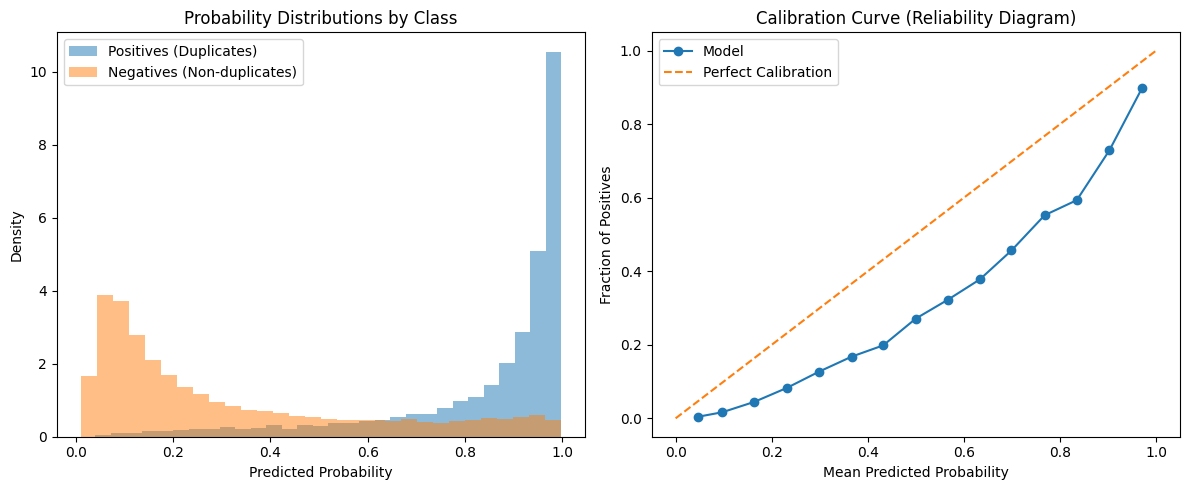


High-confidence (>0.9) false positives: 1303 out of 25503 negatives (5.11%)


In [76]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

@torch.no_grad()
def analyze_probability_distribution(model, dataloader, device):
    model.eval()
    all_probs = []
    all_labels = []
    
    for batch in tqdm(dataloader, desc="Collecting probabilities"):
        q1 = batch["q1"].to(device)
        q2 = batch["q2"].to(device)
        labels = batch["label"].cpu().numpy()
        
        logits = model(q1, q2)
        probs = torch.sigmoid(logits).cpu().numpy()
        
        all_probs.extend(probs)
        all_labels.extend(labels)
    
    probs = np.array(all_probs)
    labels = np.array(all_labels)
    
    # Histograms
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.hist(probs[labels==1], bins=30, alpha=0.5, label='Positives (Duplicates)', density=True)
    plt.hist(probs[labels==0], bins=30, alpha=0.5, label='Negatives (Non-duplicates)', density=True)
    plt.xlabel('Predicted Probability')
    plt.ylabel('Density')
    plt.legend()
    plt.title('Probability Distributions by Class')
    
    # Calibration curve
    prob_true, prob_pred = calibration_curve(labels, probs, n_bins=15)
    plt.subplot(1,2,2)
    plt.plot(prob_pred, prob_true, marker='o', label='Model')
    plt.plot([0,1],[0,1], '--', label='Perfect Calibration')
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')
    plt.legend()
    plt.title('Calibration Curve (Reliability Diagram)')
    plt.tight_layout()
    plt.show()
    
    # Statistics for high-confidence false positives
    high_conf_fp = probs[(labels==0) & (probs > 0.9)]
    print(f"\nHigh-confidence (>0.9) false positives: {len(high_conf_fp)} out of {len(probs[labels==0])} negatives ({len(high_conf_fp)/len(probs[labels==0])*100:.2f}%)")
    
    return probs, labels

probs, labels = analyze_probability_distribution(model, val_dataloader, sys_cfg.DEVICE)

In [77]:
@torch.no_grad()
def encode_with_attention(model, question):
    """
    Manually run the encoder steps and return both context vector and attention weights.
    """
    # Embedding + norm + dropout
    emb = model.embedding(question)
    emb = model.emb_norm(emb)
    emb = model.emb_dropout(emb)
    
    # LSTM
    out, _ = model.LSTM(emb)  # (batch, seq, hidden*dir)
    
    # Attention (manually compute)
    mask = (question != 0).float()  # (batch, seq)
    energy = torch.tanh(model.attention.W(out))
    scores = model.attention.V(energy).squeeze(-1)  # (batch, seq)
    scores = scores.masked_fill(mask == 0, model.attention.mask_fill_num)
    weights = F.softmax(scores, dim=-1)  # (batch, seq)
    weights = model.attention.dropout(weights)
    lstm_masked = out * mask.unsqueeze(-1)
    context = torch.bmm(weights.unsqueeze(1), lstm_masked).squeeze(1)
    
    return context, weights

In [78]:
def analyze_attention_manual(model, dataloader, device, idx2word, num_batches=10):
    model.eval()
    results = []
    
    for batch_idx, batch in enumerate(dataloader):
        if batch_idx >= num_batches:
            break
        q1 = batch["q1"].to(device)
        labels = batch["label"].cpu().numpy()
        
        # Get context and attention weights
        _, attn_weights = encode_with_attention(model, q1)  # (batch, seq_len)
        
        for i in range(q1.size(0)):
            tokens = [idx2word[idx.item()] for idx in q1[i].cpu() if idx.item() != 0]
            if not tokens:
                continue
            weights = attn_weights[i, :len(tokens)].cpu().numpy()
            top3_idx = np.argsort(weights)[::-1][:3]
            results.append({
                'label': labels[i],
                'tokens': tokens,
                'top_tokens': [tokens[j] for j in top3_idx],
                'top_weights': [weights[j] for j in top3_idx]
            })
    
    from collections import Counter
    all_top_tokens = [tok for r in results for tok in r['top_tokens']]
    token_counts = Counter(all_top_tokens)
    
    print("=== Top Attended Tokens (across all samples) ===")
    for tok, count in token_counts.most_common(20):
        print(f"  {tok}: {count}")
    
    pos_tokens = [tok for r in results if r['label']==1 for tok in r['top_tokens']]
    neg_tokens = [tok for r in results if r['label']==0 for tok in r['top_tokens']]
    pos_counter = Counter(pos_tokens)
    neg_counter = Counter(neg_tokens)
    
    print("\nTop tokens in POSITIVES:")
    for tok, count in pos_counter.most_common(10):
        print(f"  {tok}: {count}")
    print("\nTop tokens in NEGATIVES:")
    for tok, count in neg_counter.most_common(10):
        print(f"  {tok}: {count}")
    
    return results

# Run it
attn_results = analyze_attention_manual(model, val_dataloader, sys_cfg.DEVICE, idx2word)
# Compute max token attention per sample and print stopword ratio
stopwords = set(['in','a','of','on','to','for','the','and','?','.','!',',','is','it','with','at','by','from','as','an','be','this','that','these','those'])
stop_attn_ratio = []
for r in attn_results:
    top_tokens = r['top_tokens']
    stop_count = sum(1 for t in top_tokens if t.lower() in stopwords)
    stop_attn_ratio.append(stop_count / len(top_tokens))
print(f"Average stopword presence in top-3 attention: {np.mean(stop_attn_ratio):.2%}")

=== Top Attended Tokens (across all samples) ===
  in: 165
  <UNK>: 121
  a: 63
  of: 51
  on: 49
  to: 43
  for: 42
  ?: 33
  the: 29
  and: 28
  my: 28
  quora: 27
  an: 25
  at: 25
  it: 18
  with: 18
  money: 17
  about: 17
  ': 16
  is: 16

Top tokens in POSITIVES:
  in: 60
  for: 19
  a: 19
  <UNK>: 19
  to: 18
  of: 17
  quora: 17
  my: 17
  on: 14
  ?: 11

Top tokens in NEGATIVES:
  in: 105
  <UNK>: 102
  a: 44
  on: 35
  of: 34
  to: 25
  for: 23
  ?: 22
  at: 21
  the: 20
Average stopword presence in top-3 attention: 17.19%


In [65]:
@torch.no_grad()
def forward_with_features(model, q1, q2):
    """
    Runs the model forward pass and returns:
      - logits
      - fc_input (the concatenated [diff, prod, cosine] vector)
    """
    h1 = model.proj(model._encode(q1))
    h2 = model.proj(model._encode(q2))
    
    h1_norm = F.normalize(h1, p=2, dim=-1)
    h2_norm = F.normalize(h2, p=2, dim=-1)
    
    diff = torch.abs(h1_norm - h2_norm)
    prod = h1_norm * h2_norm
    cosine = (h1_norm * h2_norm).sum(dim=-1, keepdim=True)
    
    fc_input = torch.cat([diff, prod, cosine], dim=1)
    logits = model.fc(fc_input).squeeze(1)
    
    return logits, fc_input

In [67]:
def remove_all_hooks(module):
    """Recursively remove all hooks from a PyTorch module."""
    # Clear forward hooks
    module._forward_hooks.clear()
    module._forward_pre_hooks.clear()
    # Clear backward hooks
    module._backward_hooks.clear()
    module._backward_pre_hooks.clear()
    # Recursively apply to children
    for child in module.children():
        remove_all_hooks(child)

# Apply to the entire model
remove_all_hooks(model)
print("All hooks purged from model.")

All hooks purged from model.


In [68]:
# Test with a single batch
test_batch = next(iter(val_dataloader))
q1 = test_batch["q1"].to(sys_cfg.DEVICE)
q2 = test_batch["q2"].to(sys_cfg.DEVICE)
logits = model(q1, q2)
print(f"Test forward pass successful. Logits shape: {logits.shape}")

Test forward pass successful. Logits shape: torch.Size([128])


In [69]:
import numpy as np
from tqdm import tqdm

@torch.no_grad()
def extract_all_features(model, dataloader, device):
    model.eval()
    all_logits = []
    all_fc_inputs = []
    all_labels = []
    
    for batch in tqdm(dataloader, desc="Extracting features"):
        q1 = batch["q1"].to(device)
        q2 = batch["q2"].to(device)
        labels = batch["label"].cpu().numpy()
        
        logits, fc_input = forward_with_features(model, q1, q2)
        
        all_logits.append(logits.cpu().numpy())
        all_fc_inputs.append(fc_input.cpu().numpy())
        all_labels.append(labels)
    
    logits = np.concatenate(all_logits)
    fc_inputs = np.concatenate(all_fc_inputs)
    labels = np.concatenate(all_labels)
    probs = 1 / (1 + np.exp(-logits))  # sigmoid
    
    return fc_inputs, labels, probs

# Run extraction
fc_inputs, labels, probs = extract_all_features(model, val_dataloader, sys_cfg.DEVICE)
print(f"Extracted features shape: {fc_inputs.shape}")  # Should be (N, 257) for PROJ_DIM=128

Extracting features: 100%|███████████████████████████████████████████████████████████| 316/316 [00:26<00:00, 11.89it/s]

Extracted features shape: (40429, 257)


In [70]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

proj_dim = model_cfg.PROJECT_DIM  # 128

# Split the fc_input into components
diff_feat = fc_inputs[:, :proj_dim]
prod_feat = fc_inputs[:, proj_dim:2*proj_dim]
cos_feat = fc_inputs[:, -1]  # last column

# Compute L2 norms of diff and prod as summary statistics
df_stats = pd.DataFrame({
    'label': labels,
    'cos': cos_feat,
    'diff_norm': np.linalg.norm(diff_feat, axis=1),
    'prod_norm': np.linalg.norm(prod_feat, axis=1)
})

print("=== Feature Statistics by Class ===")
for cls, name in [(1, 'Positives'), (0, 'Negatives')]:
    subset = df_stats[df_stats['label'] == cls]
    print(f"\n{name}:")
    print(f"  cos mean ± std:        {subset['cos'].mean():.4f} ± {subset['cos'].std():.4f}")
    print(f"  diff_norm mean ± std:  {subset['diff_norm'].mean():.4f} ± {subset['diff_norm'].std():.4f}")
    print(f"  prod_norm mean ± std:  {subset['prod_norm'].mean():.4f} ± {subset['prod_norm'].std():.4f}")

# Check how well these features alone can classify (before FC layers)
print("\n=== Cross-validated F1 using ONLY raw comparator features ===")
clf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
scores = cross_val_score(clf, fc_inputs, labels, cv=5, scoring='f1')
print(f"5-fold CV F1: {scores.mean():.4f} ± {scores.std():.4f}")

# Compare with using only cosine
scores_cos_only = cross_val_score(clf, cos_feat.reshape(-1,1), labels, cv=5, scoring='f1')
print(f"Using only cosine: {scores_cos_only.mean():.4f} ± {scores_cos_only.std():.4f}")

=== Feature Statistics by Class ===

Positives:
  cos mean ± std:        0.8042 ± 0.1603
  diff_norm mean ± std:  0.5751 ± 0.2468
  prod_norm mean ± std:  0.2629 ± 0.1130

Negatives:
  cos mean ± std:        0.4391 ± 0.2976
  diff_norm mean ± std:  1.0071 ± 0.3278
  prod_norm mean ± std:  0.1937 ± 0.1505

=== Cross-validated F1 using ONLY raw comparator features ===
5-fold CV F1: 0.7732 ± 0.0026
Using only cosine: 0.7253 ± 0.0062


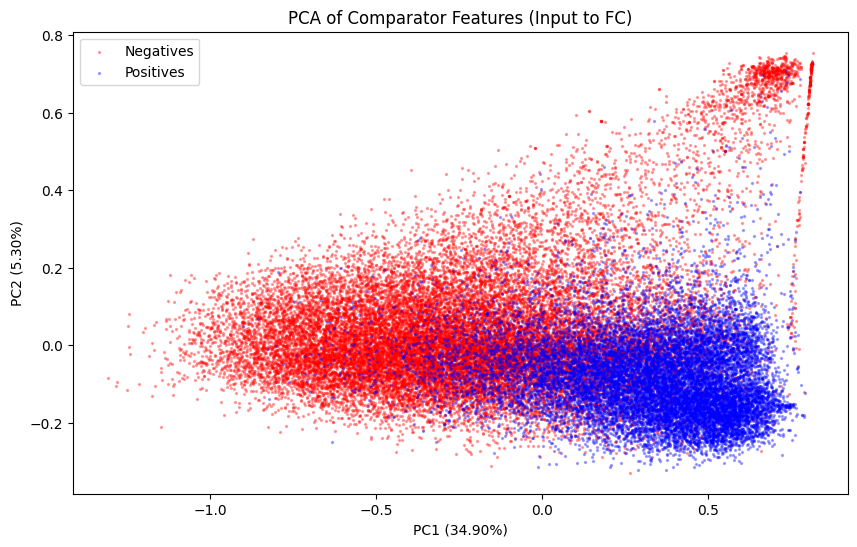

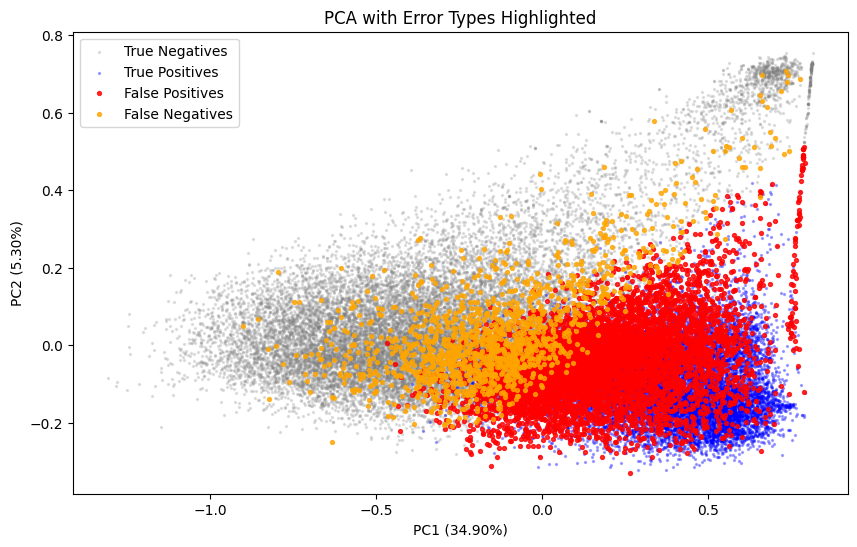

In [71]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2D
pca = PCA(n_components=2)
fc_2d = pca.fit_transform(fc_inputs)

# Plot all points
plt.figure(figsize=(10,6))
for label, color, name in [(0, 'red', 'Negatives'), (1, 'blue', 'Positives')]:
    mask = labels == label
    plt.scatter(fc_2d[mask,0], fc_2d[mask,1], c=color, label=name, alpha=0.3, s=2)
plt.legend()
plt.title('PCA of Comparator Features (Input to FC)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.show()

# Highlight False Positives (label=0, prob>0.5)
fp_mask = (labels == 0) & (probs > 0.5)
tp_mask = (labels == 1) & (probs > 0.5)
tn_mask = (labels == 0) & (probs <= 0.5)
fn_mask = (labels == 1) & (probs <= 0.5)

plt.figure(figsize=(10,6))
plt.scatter(fc_2d[tn_mask,0], fc_2d[tn_mask,1], c='gray', alpha=0.2, s=2, label='True Negatives')
plt.scatter(fc_2d[tp_mask,0], fc_2d[tp_mask,1], c='blue', alpha=0.3, s=2, label='True Positives')
plt.scatter(fc_2d[fp_mask,0], fc_2d[fp_mask,1], c='red', alpha=0.8, s=8, label='False Positives')
plt.scatter(fc_2d[fn_mask,0], fc_2d[fn_mask,1], c='orange', alpha=0.8, s=8, label='False Negatives')
plt.legend()
plt.title('PCA with Error Types Highlighted')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.show()

In [72]:
first_fc = model.fc[0]  # nn.Linear
weights = first_fc.weight.data.cpu().numpy()  # shape: (FC_DIMS[0], input_dim)
input_dim = weights.shape[1]

# Average absolute weight per input feature
avg_abs_weight = np.abs(weights).mean(axis=0)

# Split by component
diff_w = avg_abs_weight[:proj_dim]
prod_w = avg_abs_weight[proj_dim:2*proj_dim]
cos_w = avg_abs_weight[-1]

print("=== Average Absolute Weight by Component ===")
print(f"diff features:  mean={diff_w.mean():.4f}, std={diff_w.std():.4f}")
print(f"prod features:  mean={prod_w.mean():.4f}, std={prod_w.std():.4f}")
print(f"cosine feature: {cos_w:.4f}")

=== Average Absolute Weight by Component ===
diff features:  mean=0.0412, std=0.0078
prod features:  mean=0.0919, std=0.0474
cosine feature: 0.1348


In [73]:
import pandas as pd
from pathlib import Path

train_df = pd.read_csv(PathConfig.TRAIN_CSV_PATH)

# Create canonical pair representation (order-independent)
train_df['q_pair'] = train_df.apply(
    lambda r: tuple(sorted([str(r['question1']).strip(), str(r['question2']).strip()])), 
    axis=1
)

# Find pairs that appear with different labels
conflict_counts = train_df.groupby('q_pair')['is_duplicate'].nunique()
conflicting = conflict_counts[conflict_counts > 1]

print(f"Total training samples: {len(train_df)}")
print(f"Unique question pairs: {train_df['q_pair'].nunique()}")
print(f"Conflicting pairs (same text, different labels): {len(conflicting)}")

if len(conflicting) > 0:
    print("\nExample conflicting pairs:")
    for pair in conflicting.index[:5]:
        subset = train_df[train_df['q_pair'] == pair]
        print(f"\nPair: '{pair[0][:60]}...' <-> '{pair[1][:60]}...'")
        for _, row in subset.iterrows():
            print(f"  Label: {row['is_duplicate']}")

Total training samples: 404290
Unique question pairs: 404281
Conflicting pairs (same text, different labels): 0


In [74]:
pos_weight = train_dataset.pos_class_weight(sys_cfg.DEVICE)
print(f"\nComputed pos_weight: {pos_weight.item():.4f}")

# Effective probability threshold shift
import torch
eff_logit_shift = -np.log(pos_weight.item())
eff_prob_thresh = torch.sigmoid(torch.tensor(eff_logit_shift)).item()
print(f"Loss-optimal probability threshold (with BCEWithLogitsLoss + pos_weight): {eff_prob_thresh:.3f}")
print(f"This means the model is encouraged to predict POSITIVE whenever P > {eff_prob_thresh:.3f}")
print(f"(A standard 0.5 threshold corresponds to pos_weight = 1.0)")


Computed pos_weight: 1.7086
Loss-optimal probability threshold (with BCEWithLogitsLoss + pos_weight): 0.369
This means the model is encouraged to predict POSITIVE whenever P > 0.369
(A standard 0.5 threshold corresponds to pos_weight = 1.0)


In [75]:
@torch.no_grad()
def analyze_by_length(model, dataloader, device):
    model.eval()
    results = []
    for batch in dataloader:
        q1 = batch["q1"].to(device)
        q2 = batch["q2"].to(device)
        labels = batch["label"].cpu().numpy()
        logits = model(q1, q2)
        probs = torch.sigmoid(logits).cpu().numpy()
        
        len1 = (q1 != 0).sum(dim=1).cpu().numpy()
        len2 = (q2 != 0).sum(dim=1).cpu().numpy()
        avg_len = (len1 + len2) / 2
        
        for i in range(len(labels)):
            results.append({
                'label': labels[i],
                'prob': probs[i],
                'avg_len': avg_len[i],
                'pred': probs[i] > 0.5
            })
    df = pd.DataFrame(results)
    
    bins = [0, 8, 12, 16, 20, 30, 50]
    df['len_bin'] = pd.cut(df['avg_len'], bins)
    
    print("Performance by average question length (in tokens):")
    print("Length Bin   | Count | Precision | Recall | F1")
    print("-" * 50)
    for bin_name, group in df.groupby('len_bin', observed=True):
        if len(group) < 50:
            continue
        tp = ((group['pred'] == 1) & (group['label'] == 1)).sum()
        fp = ((group['pred'] == 1) & (group['label'] == 0)).sum()
        fn = ((group['pred'] == 0) & (group['label'] == 1)).sum()
        precision = tp / (tp + fp) if (tp+fp) > 0 else 0
        recall = tp / (tp + fn) if (tp+fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision+recall) > 0 else 0
        print(f"{str(bin_name):>12} | {len(group):5} | {precision:.4f}   | {recall:.4f} | {f1:.4f}")
    
    return df

len_df = analyze_by_length(model, val_dataloader, sys_cfg.DEVICE)

Performance by average question length (in tokens):
Length Bin   | Count | Precision | Recall | F1
--------------------------------------------------
      (0, 8] |  7035 | 0.6911   | 0.9297 | 0.7928
     (8, 12] | 17068 | 0.6941   | 0.9164 | 0.7899
    (12, 16] |  8443 | 0.6906   | 0.8935 | 0.7790
    (16, 20] |  4030 | 0.6919   | 0.8510 | 0.7633
    (20, 30] |  3315 | 0.7425   | 0.8246 | 0.7814
    (30, 50] |   538 | 0.7778   | 0.7000 | 0.7368


In [68]:
import torch
import numpy as np
from tqdm import tqdm

@torch.no_grad()
def raw_vector_stats(model, dataloader, device, max_batches=20):
    model.eval()
    all_dists = []
    all_labels = []
    
    for batch_idx, batch in enumerate(tqdm(dataloader, desc="Computing raw distances", total=max_batches)):
        if batch_idx >= max_batches:
            break
        q1 = batch["q1"].to(device)
        q2 = batch["q2"].to(device)
        labels = batch["label"].cpu().numpy()
        
        # Get raw encoder outputs (before projection & normalization)
        h1_raw = model._encode(q1).cpu()
        h2_raw = model._encode(q2).cpu()
        
        # Euclidean distance
        dist = torch.norm(h1_raw - h2_raw, dim=1).numpy()
        all_dists.extend(dist)
        all_labels.extend(labels)
    
    dists = np.array(all_dists)
    labels = np.array(all_labels)
    
    pos_dists = dists[labels == 1]
    neg_dists = dists[labels == 0]
    
    print(f"\n=== Raw Euclidean Distance (Before Projection & Normalization) ===")
    print(f"Positives (duplicates):   mean = {pos_dists.mean():.4f} ± {pos_dists.std():.4f}")
    print(f"Negatives (non‑duplicates): mean = {neg_dists.mean():.4f} ± {neg_dists.std():.4f}")
    print(f"Ratio (neg / pos): {neg_dists.mean() / pos_dists.mean():.3f}")
    
    # Overlap metric: percentage of negatives with distance < pos_mean
    overlap = (neg_dists < pos_dists.mean()).mean() * 100
    print(f"Percentage of negatives with distance < pos_mean: {overlap:.2f}%")

# Run it
raw_vector_stats(model, val_dataloader, sys_cfg.DEVICE)

Computing raw distances: 100%|█████████████████████████████████████████████████████████| 20/20 [00:01<00:00, 12.97it/s]


=== Raw Euclidean Distance (Before Projection & Normalization) ===
Positives (duplicates):   mean = 2.8011 ± 0.9389
Negatives (non‑duplicates): mean = 4.2462 ± 1.2349
Ratio (neg / pos): 1.516
Percentage of negatives with distance < pos_mean: 11.29%


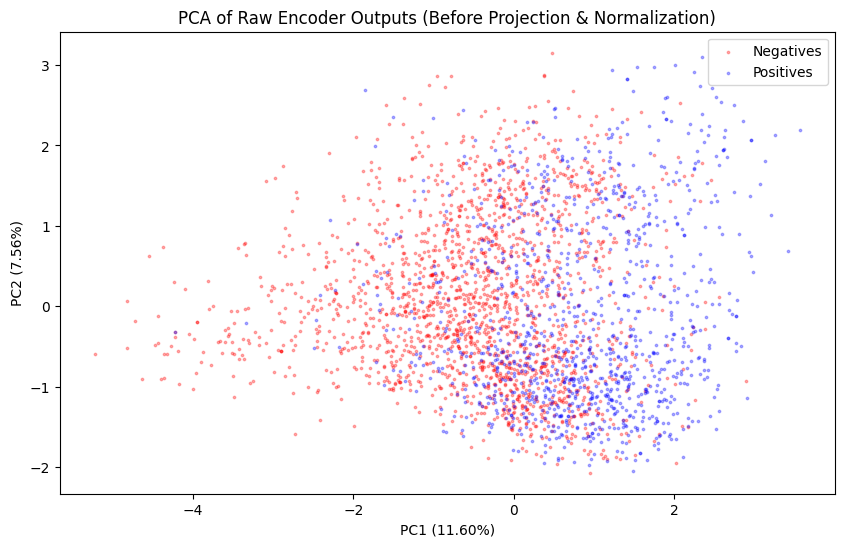

In [69]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

@torch.no_grad()
def pca_raw_vectors(model, dataloader, device, max_samples=3000):
    model.eval()
    h_list = []
    labels_list = []
    
    for batch in tqdm(dataloader, desc="Collecting raw vectors"):
        q1 = batch["q1"].to(device)
        labels = batch["label"].cpu().numpy()
        
        h = model._encode(q1).cpu().numpy()
        h_list.append(h)
        labels_list.append(labels)
        
        if sum(h.shape[0] for h in h_list) >= max_samples:
            break
    
    h_all = np.concatenate(h_list, axis=0)[:max_samples]
    labels_all = np.concatenate(labels_list)[:max_samples]
    
    # PCA
    pca = PCA(n_components=2)
    h_2d = pca.fit_transform(h_all)
    
    # Plot
    plt.figure(figsize=(10, 6))
    for label, color, name in [(0, 'red', 'Negatives'), (1, 'blue', 'Positives')]:
        mask = labels_all == label
        plt.scatter(h_2d[mask, 0], h_2d[mask, 1], c=color, label=name, alpha=0.3, s=3)
    plt.legend()
    plt.title('PCA of Raw Encoder Outputs (Before Projection & Normalization)')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
    plt.show()
    
    return h_all, labels_all

# Run it
h_raw, labels_raw = pca_raw_vectors(model, val_dataloader, sys_cfg.DEVICE)

In [67]:
raw_vector_stats(model, val_dataloader, sys_cfg.DEVICE)

Mean Euclidean distance (raw): Positives=2.8207, Negatives=4.2952


In [80]:
import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from collections import Counter
from scipy.stats import entropy  # new import

@torch.no_grad()
def encode_with_attention(model, question):
    emb = model.embedding(question)
    emb = model.emb_norm(emb)
    emb = model.emb_dropout(emb)
    out, _ = model.LSTM(emb)
    mask = (question != 0).float()
    energy = torch.tanh(model.attention.W(out))
    scores = model.attention.V(energy).squeeze(-1)
    scores = scores.masked_fill(mask == 0, model.attention.mask_fill_num)
    weights = F.softmax(scores, dim=-1)
    weights = model.attention.dropout(weights)
    lstm_masked = out * mask.unsqueeze(-1)
    context = torch.bmm(weights.unsqueeze(1), lstm_masked).squeeze(1)
    return context, weights

In [81]:
stopwords = set(['in','a','of','on','to','for','the','and','?','.','!',',','is','it','with','at','by','from','as','an','be','this','that','these','those'])

In [82]:
def compute_attention_mass_by_type(model, dataloader, device, idx2word, stopwords, num_batches=10):
    model.eval()
    stop_mass = []
    content_mass = []
    unk_mass = []
    
    for batch_idx, batch in enumerate(tqdm(dataloader, total=num_batches, desc="Attention Mass")):
        if batch_idx >= num_batches:
            break
        q1 = batch["q1"].to(device)
        _, attn_weights = encode_with_attention(model, q1)
        
        for i in range(q1.size(0)):
            tokens = [idx2word[idx.item()] for idx in q1[i].cpu() if idx.item() != 0]
            if not tokens:
                continue
            weights = attn_weights[i, :len(tokens)].cpu().numpy()
            
            stop_sum = sum(w for t, w in zip(tokens, weights) if t.lower() in stopwords)
            unk_sum = sum(w for t, w in zip(tokens, weights) if t == '<UNK>')
            content_sum = sum(w for t, w in zip(tokens, weights) if t.lower() not in stopwords and t != '<UNK>')
            
            stop_mass.append(stop_sum)
            content_mass.append(content_sum)
            unk_mass.append(unk_sum)
    
    print(f"Average attention mass on stopwords:  {np.mean(stop_mass):.3f}")
    print(f"Average attention mass on content words: {np.mean(content_mass):.3f}")
    print(f"Average attention mass on <UNK>:        {np.mean(unk_mass):.3f}")
    print(f"Ratio (content / stop): {np.mean(content_mass) / (np.mean(stop_mass) + 1e-9):.2f}")

# Execute
compute_attention_mass_by_type(model, val_dataloader, sys_cfg.DEVICE, idx2word, stopwords, num_batches=10)

Attention Mass: 100%|██████████████████████████████████████████████████████████████████| 10/10 [00:01<00:00,  8.30it/s]

Average attention mass on stopwords:  0.205
Average attention mass on content words: 0.762
Average attention mass on <UNK>:        0.033
Ratio (content / stop): 3.72


In [83]:
def attention_entropy(model, dataloader, device, num_batches=10):
    model.eval()
    entropies = []
    for batch_idx, batch in enumerate(tqdm(dataloader, total=num_batches, desc="Entropy")):
        if batch_idx >= num_batches:
            break
        q1 = batch["q1"].to(device)
        _, attn_weights = encode_with_attention(model, q1)
        for i in range(q1.size(0)):
            w = attn_weights[i].cpu().numpy()
            w = w[w > 0]  # ignore padding
            if len(w) > 1:
                entropies.append(entropy(w))
    print(f"Average attention entropy: {np.mean(entropies):.3f}")
    print(f"Max possible entropy for seq_len=50: {np.log(50):.3f}")

attention_entropy(model, val_dataloader, sys_cfg.DEVICE, num_batches=10)

Entropy: 100%|█████████████████████████████████████████████████████████████████████████| 10/10 [00:01<00:00,  6.82it/s]

Average attention entropy: 2.075
Max possible entropy for seq_len=50: 3.912


In [84]:
def compare_fp_tp_attention(model, dataloader, device, idx2word, stopwords, probs, labels, num_samples=100):
    fp_indices = np.where((labels == 0) & (probs > 0.5))[0]
    tp_indices = np.where((labels == 1) & (probs > 0.5))[0]
    
    if len(fp_indices) == 0:
        print("No false positives found.")
        return
    
    np.random.seed(42)
    fp_sample = np.random.choice(fp_indices, min(num_samples, len(fp_indices)), replace=False)
    tp_sample = np.random.choice(tp_indices, min(num_samples, len(tp_indices)), replace=False)
    
    # You need the actual dataset to get questions by index
    # Assuming val_dataset is accessible
    def get_top_stop_ratio(indices):
        ratios = []
        for idx in tqdm(indices, desc="Analyzing samples"):
            sample = val_dataset[idx]
            q1 = sample["q1"].unsqueeze(0).to(device)
            _, attn_weights = encode_with_attention(model, q1)
            tokens = [idx2word[t.item()] for t in sample["q1"] if t.item() != 0]
            if not tokens:
                continue
            weights = attn_weights[0, :len(tokens)].cpu().numpy()
            top3_idx = np.argsort(weights)[::-1][:3]
            top_tokens = [tokens[j] for j in top3_idx]
            stop_count = sum(1 for t in top_tokens if t.lower() in stopwords)
            ratios.append(stop_count / len(top_tokens))
        return np.mean(ratios) if ratios else 0
    
    fp_ratio = get_top_stop_ratio(fp_sample)
    tp_ratio = get_top_stop_ratio(tp_sample)
    print(f"FP average stopword ratio in top-3: {fp_ratio:.2%}")
    print(f"TP average stopword ratio in top-3: {tp_ratio:.2%}")

# Run (make sure probs and labels are defined from earlier Phase 1 diagnostic)
compare_fp_tp_attention(model, val_dataloader, sys_cfg.DEVICE, idx2word, stopwords, probs, labels)

Analyzing samples: 100%|█████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 81.43it/s]

FP average stopword ratio in top-3: 16.67%
TP average stopword ratio in top-3: 13.67%


In [85]:
def show_fp_examples(model, val_dataset, device, idx2word, probs, labels, num_examples=5):
    fp_indices = np.where((labels == 0) & (probs > 0.5))[0]
    if len(fp_indices) == 0:
        print("No false positives found.")
        return
    
    np.random.seed(42)
    sample_idx = np.random.choice(fp_indices, min(num_examples, len(fp_indices)), replace=False)
    
    for idx in sample_idx:
        sample = val_dataset[idx]
        q1_tokens = [idx2word[t.item()] for t in sample["q1"] if t.item() != 0]
        q2_tokens = [idx2word[t.item()] for t in sample["q2"] if t.item() != 0]
        
        q1_tensor = sample["q1"].unsqueeze(0).to(device)
        _, attn_weights = encode_with_attention(model, q1_tensor)
        weights = attn_weights[0, :len(q1_tokens)].cpu().numpy()
        top3_idx = np.argsort(weights)[::-1][:3]
        
        print(f"\n--- False Positive (prob={probs[idx]:.3f}) ---")
        print("Q1:", " ".join(q1_tokens))
        print("Q2:", " ".join(q2_tokens))
        print("Top attended tokens in Q1:")
        for j in top3_idx:
            print(f"   {q1_tokens[j]}: {weights[j]:.3f}")

# Run
show_fp_examples(model, val_dataset, sys_cfg.DEVICE, idx2word, probs, labels, num_examples=5)


--- False Positive (prob=0.657) ---
Q1: what is simple harmonic oscillation ?
Q2: what is simple harmonic motion ?
Top attended tokens in Q1:
   oscillation: 0.478
   harmonic: 0.360
   simple: 0.096

--- False Positive (prob=0.721) ---
Q1: <UNK> what are some unconventional ways to eat french fries ?
Q2: what is the best seasoning for french fries ?
Top attended tokens in Q1:
   french: 0.363
   fries: 0.319
   eat: 0.147

--- False Positive (prob=0.514) ---
Q1: what is the difference between marijuana / weed / ganja and <UNK> ?
Q2: what is the difference between smoking weed and eating it ?
Top attended tokens in Q1:
   marijuana: 0.221
   <UNK>: 0.189
   and: 0.126

--- False Positive (prob=0.733) ---
Q1: what should i have for lunch ?
Q2: what should i have for lunch today ?
Top attended tokens in Q1:
   lunch: 0.521
   for: 0.254
   have: 0.096

--- False Positive (prob=0.762) ---
Q1: do all psychopaths manipulate ?
Q2: how do psychopaths manipulate ?
Top attended tokens in Q1:
 